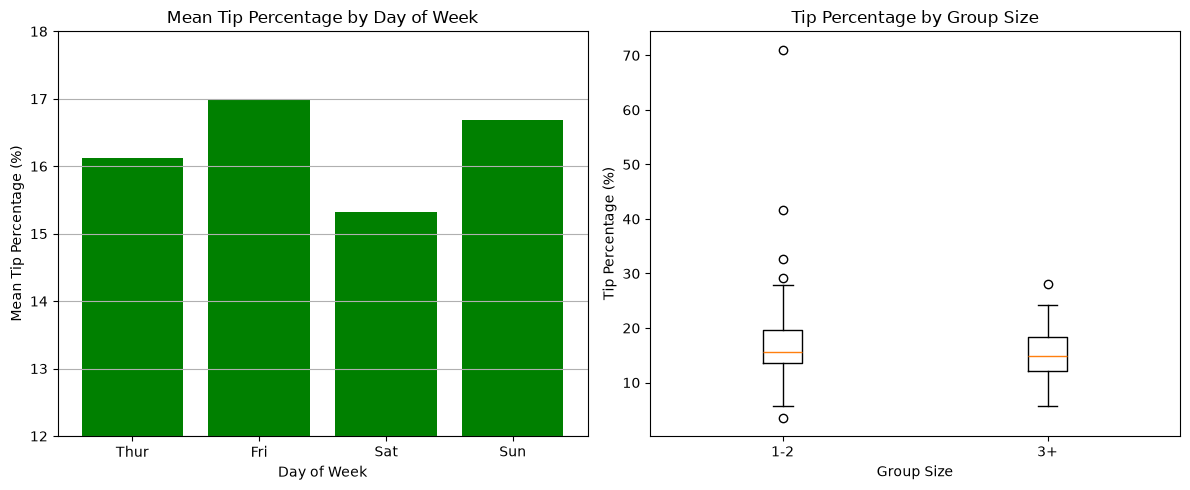

In [20]:
#1a 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the tips dataset and add the tip_pct / group columns
tips = sns.load_dataset("tips")
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100
tips["group"] = tips["size"].apply(lambda x: "1-2" if x <= 2 else "3+")

# Set up the side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: mean tip % by day (bar chart) ---
day_means = tips.groupby("day", observed=True)["tip_pct"].mean()

axes[0].bar(day_means.index, day_means.values, color="green")
axes[0].set_ylim(12, 18)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Mean Tip Percentage (%)")
axes[0].set_title("Mean Tip Percentage by Day of Week")
axes[0].grid(axis="y")

# --- Right plot: tip % distribution by group size (box plot) ---
group_data = [tips.loc[tips["group"] == g, "tip_pct"] for g in ["1-2", "3+"]]

axes[1].boxplot(group_data, tick_labels=["1-2", "3+"])
axes[1].set_xlabel("Group Size")
axes[1].set_ylabel("Tip Percentage (%)")
axes[1].set_title("Tip Percentage by Group Size")

plt.tight_layout()
plt.show()

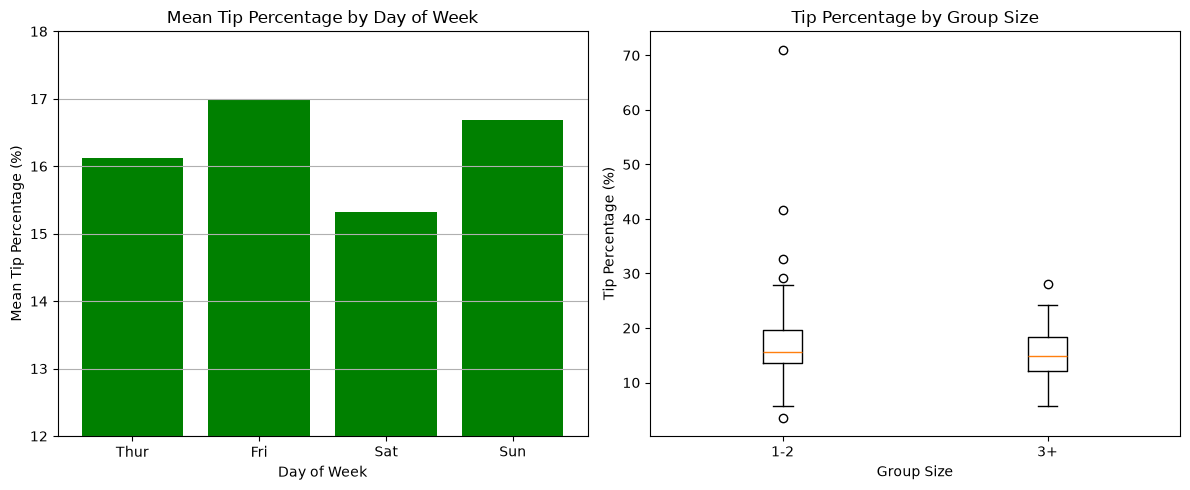

In [21]:
#1B
# Load the tips dataset
df = sns.load_dataset("tips")

# Create tip_pct column
df["tip_pct"] = df["tip"] / df["total_bill"] * 100

# Left graph: mean tip_pct by day, using groupby() and mean()
day_means = df.groupby("day", observed=True)["tip_pct"].mean()

# Right graph: the x-axis column is "size" — bucket it into a group column
df["group"] = df["size"].apply(lambda x: "1-2" if x <= 2 else "3+")

# Set up the side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: mean tip % by day (bar chart) ---
axes[0].bar(day_means.index, day_means.values, color="green")
axes[0].set_ylim(12, 18)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Mean Tip Percentage (%)")
axes[0].set_title("Mean Tip Percentage by Day of Week")
axes[0].grid(axis="y")

# --- Right plot: tip % distribution by group size (box plot) ---
group_data = [df.loc[df["group"] == g, "tip_pct"] for g in ["1-2", "3+"]]

axes[1].boxplot(group_data, tick_labels=["1-2", "3+"])
axes[1].set_xlabel("Group Size")
axes[1].set_ylabel("Tip Percentage (%)")
axes[1].set_title("Tip Percentage by Group Size")

plt.tight_layout()
plt.show()

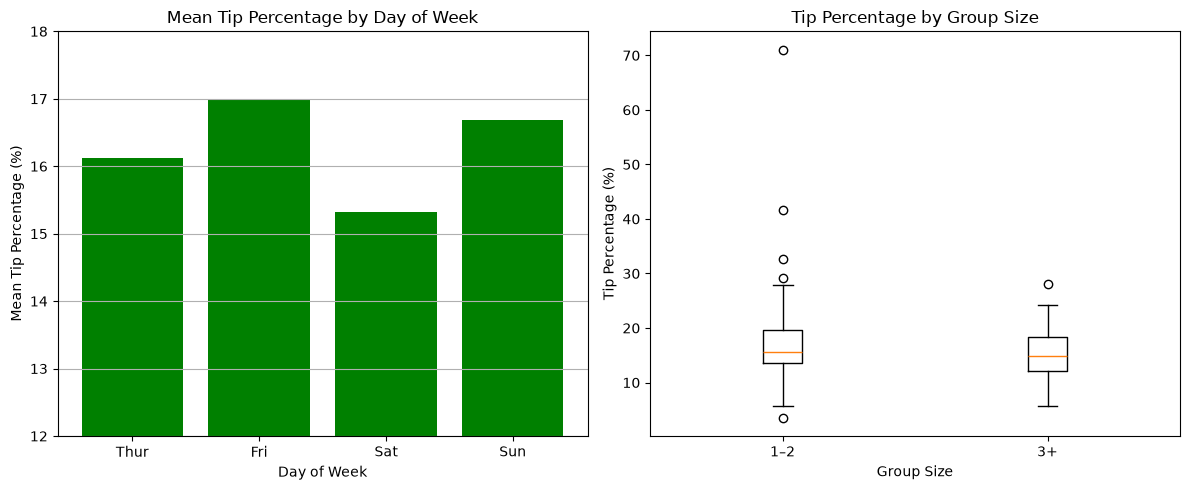

In [22]:
#1C
# Load the tips dataset
df = sns.load_dataset("tips")

# Create tip_pct column
df["tip_pct"] = df["tip"] / df["total_bill"] * 100

# Left graph: mean tip_pct by day, using groupby() and mean()
day_means = df.groupby("day", observed=True)["tip_pct"].mean()

# Right graph: bucket "size" into a group column
df["group"] = df["size"].apply(lambda x: "1-2" if x <= 2 else "3+")

# Filtered series for the boxplot
group1 = df[df["group"] == "1-2"]["tip_pct"]
group2 = df[df["group"] == "3+"]["tip_pct"]

# Set up the side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: mean tip % by day (bar chart) ---
axes[0].bar(day_means.index, day_means.values, color="green")
axes[0].set_ylim(12, 18)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Mean Tip Percentage (%)")
axes[0].set_title("Mean Tip Percentage by Day of Week")
axes[0].grid(axis="y")

# --- Right plot: tip % distribution by group size (box plot) ---
axes[1].boxplot([group1, group2], tick_labels=["1–2", "3+"])
axes[1].set_xlabel("Group Size")
axes[1].set_ylabel("Tip Percentage (%)")
axes[1].set_title("Tip Percentage by Group Size")

plt.tight_layout()
plt.show()

In [23]:
#2A 
import pandas as pd

df = pd.read_csv("Life_Expectancy", sep="\t")

life_exp_mean = df["life_expectancy"].mean()
life_exp_std = df["life_expectancy"].std()

print(f"Mean: {life_exp_mean:.2f}")
print(f"Standard Deviation: {life_exp_std:.2f}")

Mean: 76.89
Standard Deviation: 3.27


In [24]:
#2B 
life_exp_mean = df["life_expectancy"].mean()
life_exp_std = df["life_expectancy"].std()

def life_exp(value):
    if value > life_exp_mean + life_exp_std:
        return "Long"
    elif value < life_exp_mean - life_exp_std:
        return "Short"
    else:
        return "Average"

df["category"] = df["life_expectancy"].apply(life_exp)

In [25]:
#2C 
df_filtered = df[df["category"] != "Average"]

print(df_filtered["category"].value_counts())

category
Short    415
Long     403
Name: count, dtype: int64


In [26]:
#2D
from sklearn.preprocessing import label_binarize

# classes=["Short", "Long"] means Short -> 0, Long -> 1
df_filtered["category_binary"] = label_binarize(
    df_filtered["category"], classes=["Short", "Long"]
).ravel()

print(df_filtered[["category", "category_binary"]].drop_duplicates())

   category  category_binary
2     Short                0
58     Long                1


In [27]:
#2E
df_filtered = df_filtered.drop(columns=["Year", "County_Name", "State_Name", "life_expectancy"])

print(df_filtered.columns)

Index(['diversity', 'smoking', 'obesity', 'house_income', 'unemployment_rate',
       'pct_edu_or_health', 'category', 'category_binary'],
      dtype='str')


In [28]:
#2F
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

X = df_filtered[['diversity', 'smoking', 'obesity', 'house_income', 'unemployment_rate', 'pct_edu_or_health']]
y = df_filtered['category']

# --- KNN grid search ---
knn_param_grid = {
    'n_neighbors': [3, 5],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring='roc_auc',
    cv=5
)
knn_grid.fit(X, y)
knn_results = pd.DataFrame(knn_grid.cv_results_)

# --- Decision Tree grid search ---
dt_param_grid = {
    'max_depth': [5, None],
    'min_samples_split': [5, 10]
}
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=dt_param_grid,
    scoring='roc_auc',
    cv=5
)
dt_grid.fit(X, y)
dt_results = pd.DataFrame(dt_grid.cv_results_)

# Display results as DataFrames
print("KNN Grid Search Results:")
display(knn_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
        .sort_values('mean_test_score', ascending=False))

print("Decision Tree Grid Search Results:")
display(dt_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
        .sort_values('mean_test_score', ascending=False))

print("Best KNN:", knn_grid.best_params_, "AUC:", knn_grid.best_score_)
print("Best Decision Tree:", dt_grid.best_params_, "AUC:", dt_grid.best_score_)

KNN Grid Search Results:


,params,mean_test_score,std_test_score,rank_test_score
3,"{'metric': 'manhattan', 'n_neighbors': 5}",0.942863,0.013017,1
1,"{'metric': 'euclidean', 'n_neighbors': 5}",0.940775,0.015322,2
2,"{'metric': 'manhattan', 'n_neighbors': 3}",0.929845,0.018433,3
0,"{'metric': 'euclidean', 'n_neighbors': 3}",0.927807,0.018384,4


Decision Tree Grid Search Results:


,params,mean_test_score,std_test_score,rank_test_score
3,"{'max_depth': None, 'min_samples_split': 10}",0.957078,0.016116,1
1,"{'max_depth': 5, 'min_samples_split': 10}",0.954826,0.019634,2
2,"{'max_depth': None, 'min_samples_split': 5}",0.949918,0.018825,3
0,"{'max_depth': 5, 'min_samples_split': 5}",0.945549,0.015133,4


Best KNN: {'metric': 'manhattan', 'n_neighbors': 5} AUC: 0.9428633050721403
Best Decision Tree: {'max_depth': None, 'min_samples_split': 10} AUC: 0.9570777554663097
